In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from math import factorial
from matplotlib import pyplot as plt
from scipy.stats import levene
import scipy.stats as stats

# Importacion de datos 

se importaron los datos para el analisis asignando el nombre a las siguientes variables :

dataset_taxi = project_sql_result_01.csv
travel_chicago = project_sql_result_04.csv
date_travel = project_sql_result_07.csv


In [4]:
dataset_taxi=pd.read_csv('/datasets/project_sql_result_01.csv')
travel_chicago=pd.read_csv('/datasets/project_sql_result_04.csv')
date_travel=pd.read_csv('/datasets/project_sql_result_07.csv')

In [5]:
dataset_taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [6]:
travel_chicago.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


# ANALISIS DE DATOS 

tras analisar los datos de date_travel se cambio a tipo fecha utilizando pd.to_datetime para una mejor comprension y  analisis  ya que no tener los datos en formato adecuado puede alterar y afectar nuestro resultado.

In [7]:
date_travel.info()
date_travel['start_ts'] = pd.to_datetime(date_travel['start_ts'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [8]:
top_10_barrios =travel_chicago.sort_values(by='average_trips', ascending=False).head(11)
print(top_10_barrios)

   dropoff_location_name  average_trips
0                   Loop   10727.466667
1            River North    9523.666667
2          Streeterville    6664.666667
3              West Loop    5163.666667
4                 O'Hare    2546.900000
5              Lake View    2420.966667
6             Grant Park    2068.533333
7          Museum Campus    1510.000000
8             Gold Coast    1364.233333
9     Sheffield & DePaul    1259.766667
10          Lincoln Park    1246.533333



# Grafica empresas de taxis y número de viajes

en la grafica de barras presente se puede observar cuales son las compañias de taxis que mas viajes realizaron entre el 15 y 16 de noviembre teniendo en primer lugar ala compañia Flash Cab mientras que la compañia que menos viajes realizo es es -3556 - 36214 RC Andrews Cab

1 Flash Cab siendo la compañia lider de viajes con 19558
2-Taxi Affiliation Services en segundo lugar con 11422 viajes
3-Medallion Leasin con 10367 viajes
4-Yellow Cab con 9888 viajes
65 -3556 - 36214 RC Andrews Cab 2 viajes 

Existen muchas compañías pequeñas que tienen un número mucho menor de viajes stas empresas representan una proporción más pequeña del mercado total y podrían estar enfocadas en regiones específicas

La gráfica sugiere que el mercado está dominado por unas pocas compañías  mientras que una gran cantidad de empresas tienen un bajo número de viajes, lo que refleja una distribución desigual.

se puede observar una cosiderable preferencia de la compañia Flash Cab sobre las demas algunas de las hipotesis que posiblemente podrian explicar el fenomeno son :

la compañia de taxis mas famosa en la zona y grande 
mas unidades disponibles que abarquen mas territorio
una posible app de viajes 
tarifas mas disponibles o mas adecuadas 
beneficios,descuentos y promociones
seguridad y comodidad sobre las demas 


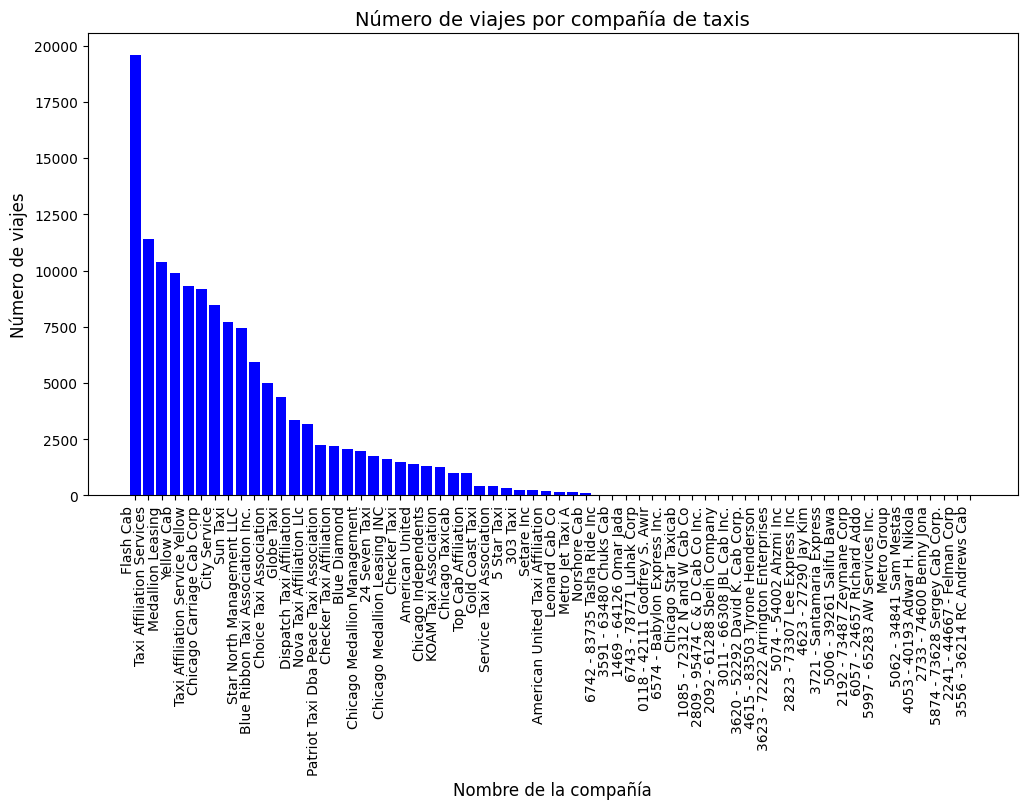

In [9]:
dataset_taxi = dataset_taxi.sort_values(by='trips_amount', ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(dataset_taxi['company_name'], dataset_taxi['trips_amount'], color='blue')
plt.xlabel('Nombre de la compañía', fontsize=12)
plt.ylabel('Número de viajes', fontsize=12)
plt.title('Número de viajes por compañía de taxis', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.show()

# Grafica los 10 barrios principales por número de finalizaciones

la grafica representa los 10 barrios principales por numero de finalizaciones siendo el barrio  LOOP que mas se frecuenta entre la gente 

El barrio Loop lidera claramente: Es el barrio con el mayor promedio de finalizaciones de recorrido, superando ampliamente a los demás barrios. Esto sugiere que es una zona muy activa y probablemente sea un importante destino para transporte.

River North y Streeterville también son destacados: Estos barrios ocupan el segundo y tercer lugar respectivamente, lo que indica que también tienen una alta demanda como destinos.

 West Loop y O'Hare: Aunque están por debajo de Loop, River North y Streeterville, tienen una actividad considerable mientras que O'Hare es un aeropuerto por lo que es cosiderable que usuarios lleguen a ese destino 

Los barrios de menor promedio: Barrios como Lincoln Park, Sheffield & DePaul y Gold Coast tienen un menor promedio de finalizaciones, lo que podría sugerir que son menos populares 

los destinos mas frecuentes podrian estar relacionados en areas centrales,zonas de entretenimiento , actividades comerciales turisticas,negocios etc.  

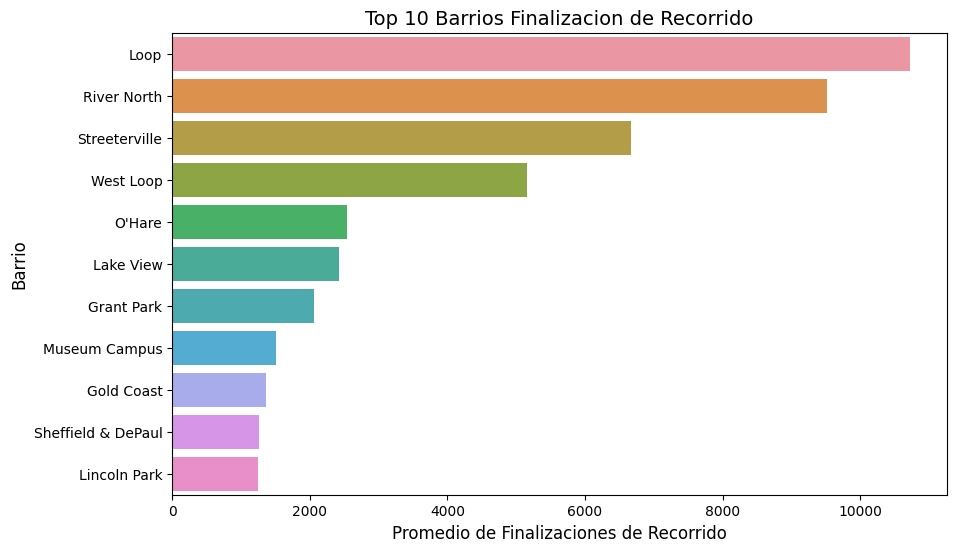

In [10]:
top_10=travel_chicago.sort_values(by='average_trips', ascending=False).head(11)

plt.figure(figsize=(10, 6))
sns.barplot(x='average_trips', y='dropoff_location_name', data=top_10_barrios)

# Títulos y etiquetas
plt.title('Top 10 Barrios Finalizacion de Recorrido', fontsize=14)
plt.xlabel('Promedio de Finalizaciones de Recorrido', fontsize=12)
plt.ylabel('Barrio', fontsize=12)

# Mostrar el gráfico
plt.show()

# Prueba la hipótesis:

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Decide por tu cuenta dónde establecer el nivel de significación (alfa).

Explica:

 cómo planteaste las hipótesis nula y alternativa
 qué criterio usaste para probar las hipótesis y por qué
 
 
Se planteo la hipotesis a raiz de conocer si La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos
 
hipotesis nula : no hay una diferencia significativa entre los viajes del dia sabado es decir las  medias de las duraciones de los viajes en los dos grupos (buen clima y mal clima ) son iguales.

hipotesis alternativa  existe una diferencia significativa en los tiempos de los viajes es decir las medias de las duraciones de los viajes no son iguales.

para llegar a probar mi hipotesis,primero tuve que filtrar para obtener datos del dia sabado con buen y mal clima que estas serian mis muestras con las que iba a trabajar, para posteriromente sacar el promedio de sabados lluviosos y dias no lluviosos,seguido a esto aplicar la prueba levene que nos ayudaria a verifica si las varianzas de dos o más grupos son iguales o si hay diferencias significativas entre ellas al ser muy parecidas se opto por  la prueba t estándar de Student.

Se realiza una prueba t de Student para comparar las medias de las dos muestras (sabados con mal clima y sabado con buen clima ). El argumento equal_var=True asume que las varianzas de las dos poblaciones son iguales.

Al ser el valor p menor que el nivel de significancia 0.05 se rechaza la hipótesis nula. Esto significa que podemos concluir con un alto grado de confianza que existe una diferencia estadísticamente significativa en los tiempos de los viajes de los dias sabados 

para concluir el clima (bueno o malo) tiene un impacto significativo en la duración de los viajes los sábados.
 

In [11]:
date_travel['day_of_week'] = date_travel['start_ts'].dt.day_name()
saturdays = date_travel[date_travel['day_of_week'] == 'Saturday']

rainy_saturdays = saturdays[saturdays['weather_conditions'].str.contains('Bad', case=False)]
non_rainy_saturdays = saturdays[~saturdays['weather_conditions'].str.contains('Bad', case=False)]

rainy_mean = rainy_saturdays['duration_seconds'].mean()
non_rainy_mean = non_rainy_saturdays['duration_seconds'].mean()


print(f"Duración promedio en sábados lluviosos: {rainy_mean:f} segundos")
print(f"Duración promedio en sábados no lluviosos: {non_rainy_mean:f} segundos")

      


Duración promedio en sábados lluviosos: 2427.205556 segundos
Duración promedio en sábados no lluviosos: 1999.675676 segundos


In [12]:
rainy_saturdays_duration = rainy_saturdays['duration_seconds']
non_rainy_saturdays_duration = non_rainy_saturdays['duration_seconds']

levene_test_result = levene(rainy_saturdays_duration, non_rainy_saturdays_duration)
print(f"Estadístico de Levene: {levene_test_result.statistic}")
print(f"Valor p de Levene: {levene_test_result.pvalue}")

if levene_test_result.pvalue < 0.05:
    print("Las varianzas son significativamente diferentes.")
else:
    print("No hay evidencia suficiente para afirmar que las varianzas son diferentes.")

Estadístico de Levene: 0.38853489683656073
Valor p de Levene: 0.5332038671974493
No hay evidencia suficiente para afirmar que las varianzas son diferentes.


In [13]:
alpha=0.05

t_stat,p_value = stats.ttest_ind(rainy_saturdays_duration, non_rainy_saturdays_duration, equal_var=True)
print(f"Estadístico t: {t_stat}")
print(f"Valor p de la prueba t: {p_value}")

# Realizamos la interpretación del valor p de la prueba t
if p_value < alpha:
    print("Rechazamos la hipótesis nula. Existe una diferencia significativa en las duraciones de los viajes.")
else:
    print("No podemos rechazar la hipótesis nula. No hay evidencia suficiente para afirmar que las duraciones son diferentes.")

Estadístico t: 6.946177714041499
Valor p de la prueba t: 6.517970327099473e-12
Rechazamos la hipótesis nula. Existe una diferencia significativa en las duraciones de los viajes.
